# Install Required Libraries

In [ ]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 12.2 MB/s eta 0:00:00


# Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pmdarima import auto_arima
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX



# Read  Sample Data

In [ ]:
df_daily = pd.read_csv('data/sample_dump.csv')
print(df_daily.head())

   Unnamed: 0          dt    f1    f5      f2     f4  agg       f3    cd_f1  \
0           0  2021-12-14  2147  3010  1086.0  426.0  NaN  23375.0  2453886   
1           1  2021-12-15  1937  2675  1075.0  372.0  NaN  20596.0  2455823   
2           2  2021-12-16  1888  2767   998.0  388.0  NaN  22040.0  2457711   
3           3  2021-12-17  1445  2209   893.0  330.0  NaN  18179.0  2459156   
4           4  2021-12-18   611   821   432.0   84.0  NaN   6078.0  2459767   

     cd_f5  ...  cd_agg       cd_f3     Size  cd_coper  sz_anal  cd_anal  \
0  2652343  ...     NaN  25751292.0  2655189    -15674  1931096     1037   
1  2655018  ...     NaN  25771888.0  2660503      5314  1933663     2567   
2  2657785  ...     NaN  25793928.0  2662213      1710  1935328     1665   
3  2659994  ...     NaN  25812107.0  2663908      1695  1937038     1710   
4  2660815  ...     NaN  25818185.0  2657027     -6881  1938254     1216   

   sz_dist  cd_dist  sz_logg  cd_logg  
0  2932359    19192  1744937

### Display Data

In [ ]:

from IPython.display import display, HTML
style = """
<style>
    .scrollable-table {
        width: 1500px;
        height: 400px;
        overflow: auto;
        border: 1px solid black;
    }
    table {
        border-collapse: collapse;
        width: 100%;
    }
    th, td {
        border: 1px solid black;
        padding: 8px;
        text-align: center;
    }
    thead th {
        position: sticky;
        top: 0;
        background-color: #f1f1f1;
        z-index: 1;
    }
</style>
"""

# Convert DataFrame to HTML with proper table ID
html_table = df_daily[['dt','Size','f1','f2','f3','f4','f5','cd_f1','cd_f2','cd_f3','cd_f4','cd_f5']].to_html(index=True)

# Wrap in scrollable div with styling
final_html = f"{style}<div class='scrollable-table'>{html_table}</div>"

# Display
display(HTML(final_html))


,dt,Size,f1,f2,f3,f4,f5,cd_f1,cd_f2,cd_f3,cd_f4,cd_f5
0,2021-12-14,2655189,2147,1086.0,23375.0,426.0,3010,2453886,1313471.0,25751292.0,446203.0,2652343
1,2021-12-15,2660503,1937,1075.0,20596.0,372.0,2675,2455823,1314546.0,25771888.0,446575.0,2655018
2,2021-12-16,2662213,1888,998.0,22040.0,388.0,2767,2457711,1315544.0,25793928.0,446963.0,2657785
3,2021-12-17,2663908,1445,893.0,18179.0,330.0,2209,2459156,1316437.0,25812107.0,447293.0,2659994
4,2021-12-18,2657027,611,432.0,6078.0,84.0,821,2459767,1316869.0,25818185.0,447377.0,2660815
5,2021-12-19,2658165,545,425.0,5089.0,46.0,761,2460312,1317294.0,25823274.0,447423.0,2661576
6,2021-12-20,2668244,1797,1014.0,22691.0,371.0,2793,2462109,1318308.0,25845965.0,447794.0,2664369
7,2021-12-21,2662697,2084,1111.0,23114.0,425.0,3288,2464193,1319419.0,25869079.0,448219.0,2667657
8,2021-12-22,2664409,1725,1072.0,21548.0,403.0,2870,2465918,1320491.0,25890627.0,448622.0,2670527
9,2021-12-23,2669459,1884,1061.0,36558.0,412.0,2954,2467802,1321552.0,25927185.0,449034.0,2673481


# Treat missing data

In [ ]:
# Before any operations, ensure 'dt' is a column if it's currently the index
if 'dt' not in df_daily.columns and df_daily.index.name == 'dt':
    df_daily = df_daily.reset_index()

df_daily = df_daily.dropna(subset=['dt'])

# Columns to process
cols_to_fill = ['Size','cd_f1', 'cd_f2', 'cd_f3', 'cd_f4', 'cd_f5','f1','f2','f3','f4','f5']

for col in cols_to_fill:
    # Forward fill
    df_daily[col] = df_daily[col].ffill()
    # Backward fill
    df_daily[col] = df_daily[col].bfill()

    # Calculate the average of previous and next valid values for remaining nulls
    null_indices = df_daily[df_daily[col].isnull()].index

    for idx in null_indices:
        prev_valid_val = df_daily.loc[:idx, col].last_valid_index()
        next_valid_val = df_daily.loc[idx:, col].first_valid_index()

        if pd.isnull(prev_valid_val) or pd.isnull(next_valid_val) or pd.isna(prev_valid_val) or pd.isna(next_valid_val):
           # If no valid previous or next values, remove the null row
           df_daily = df_daily.drop(index=idx)
        else:
           df_daily.loc[idx, col] = (df_daily.loc[prev_valid_val, col] + df_daily.loc[next_valid_val, col]) / 2

# Convert 'dt' to datetime objects if not already
df_daily['dt'] = pd.to_datetime(df_daily['dt'])

# Set 'dt' as the index
df_daily = df_daily.set_index('dt')

# Plot  Covariance

In [ ]:
cor_matrix=df_daily[['Size','f1','f2','f3','f4','f5','cd_f1','cd_f2','cd_f3','cd_f4','cd_f5']]

<Axes: >

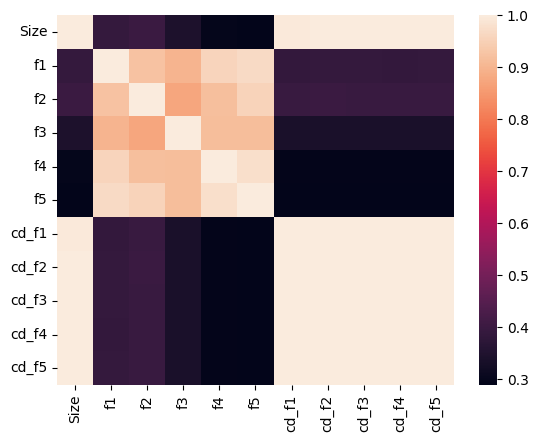

In [ ]:
sns.heatmap(cor_matrix.corr())

# Build AutoArima and SARIMAX Models

In [ ]:
# Assuming df_daily is already loaded and preprocessed

# Define training and validation sets
train_data = df_daily[ ( df_daily.index >= pd.Timestamp('2024-06-01'))&( df_daily.index < pd.Timestamp('2025-09-14'))]
#validation_data = df_daily[(df_daily.index >= pd.Timestamp('2025-03-01')) & (df_daily.index <= pd.Timestamp('2025-04-30'))]
validation_data = df_daily[(df_daily.index >= pd.Timestamp('2025-09-15'))]

# Check if numerical columns exist in the dataset
numerical_cols = ['Size', 'cd_f1', 'cd_f4',  'cd_f2', 'cd_f5']
other_cols = ['cd_f1', 'cd_f4',  'cd_f2', 'cd_f5']
target_col=['Size']
if not all(col in df_daily.columns for col in numerical_cols):
    raise ValueError("One or more required columns are missing in the dataset.")

# Scale numerical features
#scaler = MinMaxScaler()
#feature_scaler=MinMaxScaler()
#target_scaler=MinMaxScaler()
feature_scaler=StandardScaler()
target_scaler=StandardScaler()
train_feature_scaled = feature_scaler.fit_transform(train_data[other_cols])
train_scaled_df = pd.DataFrame(train_feature_scaled, index=train_data.index, columns=other_cols)

train_target_scaled = target_scaler.fit_transform(train_data[target_col])
train_target_scaled_df = pd.DataFrame(train_target_scaled, index=train_data.index, columns=target_col)

validation_feature_scaled = feature_scaler.transform(validation_data[other_cols])
validation_scaled_df = pd.DataFrame(validation_feature_scaled, index=validation_data.index, columns=other_cols)
validation_target_scaled = target_scaler.transform(validation_data[target_col])
validation_target_scaled_df = pd.DataFrame(validation_target_scaled, index=validation_data.index, columns=target_col)

n_periods = len(validation_scaled_df)
# Forecast from end of training data
start = len(train_scaled_df)
end = start + n_periods - 1

# Fit auto_arima model with Scaler Values
model = auto_arima(
    train_target_scaled_df.values.ravel(),
    exogenous=train_scaled_df.values,
    m=7,
    trace=True,
    start_p=0, max_p=7,
    start_q=0, max_q=7,
    seasonal=True,
    d=None,  # Automatically determine differencing
    D=None,  # Automatically determine seasonal differencing
    error_action='ignore',
    stepwise=True,  # Disable stepwise for thorough search
    information_criterion='aic'
)

# Print the model summary
print(model.summary())

manual_model = SARIMAX(
    endog=train_target_scaled_df.values.ravel(),
    exog=train_scaled_df.values,
    order=(1,1,1),
    seasonal_order=(0,1,1,7),
    enforce_stationarity=False,
    enforce_invertibility=False,
    trend='n'
)

manual_result = manual_model.fit()
print(manual_result.summary())




# Make predictions on the validation set
predictions_scaled = model.predict(
    n_periods=len(validation_scaled_df),
    exogenous=validation_scaled_df
)

forecast_obj = manual_result.get_forecast(
    steps=len(validation_scaled_df),
    exog=validation_scaled_df.values
)

predictions_scaled_m = forecast_obj.predicted_mean

predictions_scaled = np.array(predictions_scaled).reshape(-1, 1)
predictions_scaled_m = np.array(predictions_scaled_m).reshape(-1, 1)

# Combine predictions with validation features for inverse scaling
#combined_scaled = np.concatenate(
 #   [predictions_scaled, validation_scaled_df[['cd_quote', 'cd_contract',  'cd_app', 'cd_client']].values],
 #   axis=1
#)

# Inverse transform to get actual values
predictions = target_scaler.inverse_transform(predictions_scaled.reshape(-1,1))
predictions_m = target_scaler.inverse_transform(predictions_scaled_m.reshape(-1,1))
# Evaluate the model
rmse = np.sqrt(mean_squared_error(validation_data['Size'], predictions))
print(f'RMSE: {rmse}')

rmse = np.sqrt(mean_squared_error(validation_data['Size'], predictions_m))
print(f'RMSE: {rmse}')


Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[7] intercept   : AIC=inf, Time=0.58 sec
 ARIMA(0,1,0)(0,0,0)[7] intercept   : AIC=-1253.584, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[7] intercept   : AIC=-1271.575, Time=0.30 sec
 ARIMA(0,1,1)(0,0,1)[7] intercept   : AIC=-1294.518, Time=0.42 sec
 ARIMA(0,1,0)(0,0,0)[7]             : AIC=-1249.047, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[7] intercept   : AIC=-1296.020, Time=0.10 sec
 ARIMA(0,1,1)(1,0,0)[7] intercept   : AIC=-1294.629, Time=0.23 sec
 ARIMA(0,1,1)(1,0,1)[7] intercept   : AIC=inf, Time=0.96 sec
 ARIMA(1,1,1)(0,0,0)[7] intercept   : AIC=-1311.461, Time=0.22 sec
 ARIMA(1,1,1)(1,0,0)[7] intercept   : AIC=-1311.155, Time=0.47 sec
 ARIMA(1,1,1)(0,0,1)[7] intercept   : AIC=-1310.836, Time=0.52 sec
 ARIMA(1,1,1)(1,0,1)[7] intercept   : AIC=-1315.881, Time=0.89 sec
 ARIMA(1,1,1)(2,0,1)[7] intercept   : AIC=-1319.372, Time=2.45 sec
 ARIMA(1,1,1)(2,0,0)[7] intercept   : AIC=-1313.685, Time=1.12 sec
 ARIMA(1,1,1)(2,0,2)[7] interce

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


# Check RMSE and MAPE

In [ ]:
print("Scaled SARIMAX forecast range")
print(predictions_scaled_m.min())
print(predictions_scaled_m.max())

print("Scaled Validation Target range")
print(validation_target_scaled_df.min())
print(validation_target_scaled_df.max())

print("Scaled Validation range")
print(validation_scaled_df.min())
print(validation_scaled_df.max())
mape = np.mean(
np.abs(
(validation_data['Size'] - predictions_m.flatten())
/ validation_data['Size']
)
) * 100
print('MAPE')
print(mape)

Scaled SARIMAX forecast range
1.867852684567107
3.8206448158086
Scaled Validation Target range
Size    1.895423
dtype: float64
Size    2.836641
dtype: float64
Scaled Validation range
cd_f1    1.754624
cd_f4    1.761187
cd_f2    1.887340
cd_f5    1.816191
dtype: float64
cd_f1    2.397191
cd_f4    2.437709
cd_f2    2.809861
cd_f5    2.550242
dtype: float64
MAPE
2.8127653580862986


# Plot Prediction and Validation


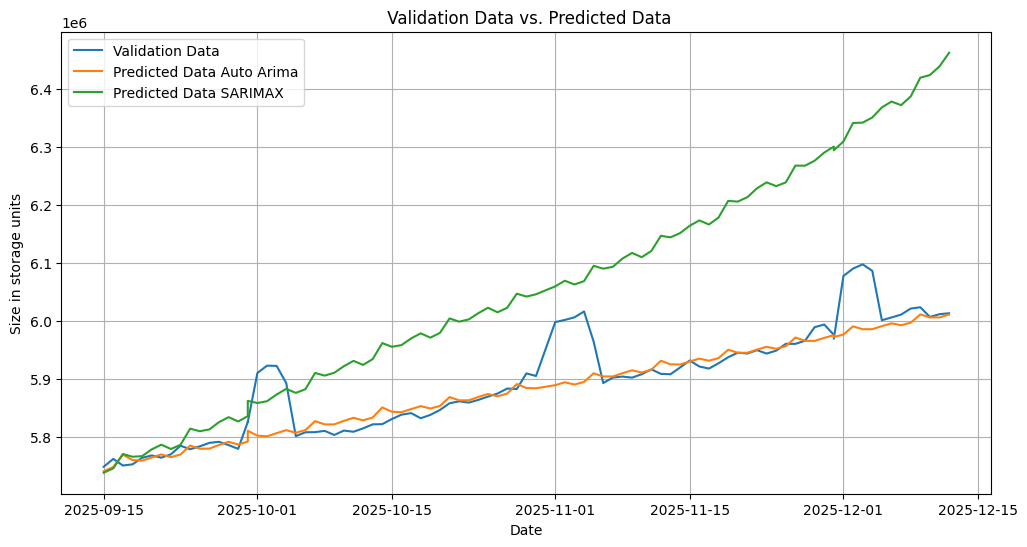

In [ ]:
# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(validation_data.index, validation_data['Size'], label='Validation Data')
plt.plot(validation_data.index, predictions, label='Predicted Data Auto Arima')
plt.plot(validation_data.index, predictions_m, label='Predicted Data SARIMAX')
plt.xlabel('Date')
plt.ylabel('Size in storage units')
plt.title(' Validation Data vs. Predicted Data')
plt.legend()
plt.grid(True)
plt.show()


# Future Data (Attributes)

###  Calibrate Growth Rate of f1,f2,f3,f4,f5 from its Cummulative value


In [ ]:
# prompt: get the average growth of predicted sz_coper as percentage  and value and by actual

# Calculate the average growth rate of predicted and actual 'sz_coper'

# Calculate percentage change for predicted values
predicted_growth_percentage = predictions[1:] / predictions[:-1] - 1

# Calculate percentage change for actual values
actual_growth_percentage = validation_data['Size'].values[1:] / validation_data['Size'].values[:-1] - 1

# Calculate the average growth rate as percentage for predictions
avg_predicted_growth_percentage = np.mean(predicted_growth_percentage) * 100

# Calculate the average growth rate as percentage for actual values
avg_actual_growth_percentage = np.mean(actual_growth_percentage) * 100

# Calculate the average growth for predicted values
avg_predicted_growth_value = np.mean(predictions[1:] - predictions[:-1])

# Calculate the average growth for actual values
avg_actual_growth_value = np.mean(validation_data['Size'].values[1:] - validation_data['Size'].values[:-1])

cols_to_analyze = numerical_cols
avg_growth_values = {}

for col in cols_to_analyze:
    # Calculate the difference between consecutive values
    growth_values = df_daily[col].diff()

    # Calculate the average growth value, excluding the first value (NaN due to diff)
    avg_growth = np.mean(growth_values.dropna())
    avg_growth_values[col] = avg_growth

# Print the results
for col, avg_growth in avg_growth_values.items():
    print(f"Average growth value for {col}: {avg_growth:.2f}")


Average growth value for Size: 2656.64
Average growth value for cd_f1: 2672.67
Average growth value for cd_f4: 485.12
Average growth value for cd_f2: 1386.50
Average growth value for cd_f5: 3518.52


###  Generte Future business drives as per above growth rates

In [ ]:
# Create an empty DataFrame to store the future predictions
# Define the number of future periods to forecast. Let's use the same number of periods as the validation set for consistency.
n_future_periods = len(validation_data)+180
# Or define a different number if needed

# Generate future dates starting from the day after the last date in df_daily
future_dates = pd.date_range(start=df_daily.index[-30] + pd.Timedelta(days=1),
                             periods=n_future_periods,
                             freq='D')
future_data = pd.DataFrame(index=future_dates, columns=numerical_cols)
future_data_20pct = pd.DataFrame(index=future_dates, columns=numerical_cols)
future_data['Size']=0.0
future_data_20pct['Size']=0.0
# Initialize the future data with the last known values
future_data.iloc[0] = df_daily[numerical_cols].iloc[-1]
future_data_20pct.iloc[0] = df_daily[numerical_cols].iloc[-1]
# Generate future data based on average growth rates
for i in range(1, len(future_data)):
    for col in numerical_cols:
        future_data.loc[future_data.index[i], col] = future_data.loc[future_data.index[i-1], col] + avg_growth_values[col]
        future_data_20pct.loc[future_data_20pct.index[i], col] = future_data_20pct.loc[future_data_20pct.index[i-1], col] + (.9*avg_growth_values[col])
# Display or use the future_data DataFrame

future_data['Size']=0.0
future_data_20pct['Size']=0.0
print(future_data)
print(future_data_20pct)



            Size           cd_f1           cd_f4           cd_f2  \
2025-11-15   0.0       5832137.0       1059397.0       3066010.0   
2025-11-16   0.0   5834809.66693  1059882.121835  3067396.502373   
2025-11-17   0.0  5837482.333861  1060367.243671  3068783.004747   
2025-11-18   0.0  5840155.000791  1060852.365506   3070169.50712   
2025-11-19   0.0  5842827.667722  1061337.487342  3071556.009494   
...          ...             ...             ...             ...   
2026-08-07   0.0  6540393.736551  1187954.286392  3433433.128956   
2026-08-08   0.0  6543066.403481  1188439.408228  3434819.631329   
2026-08-09   0.0  6545739.070411  1188924.530063  3436206.133703   
2026-08-10   0.0  6548411.737342  1189409.651899  3437592.636076   
2026-08-11   0.0  6551084.404272  1189894.773734  3438979.138449   

                     cd_f5  
2025-11-15       7099756.0  
2025-11-16  7103274.522943  
2025-11-17  7106793.045886  
2025-11-18  7110311.568829  
2025-11-19  7113830.091772  
...      

# Predict future using Average with SARIMAX

In [ ]:
# prompt: predict sz_coper with with two data set future_data and future_data_20pct  using model  manual_model SARIMAX
future_feature_scaled = feature_scaler.transform(future_data[other_cols])
future_scaled_df = pd.DataFrame(future_feature_scaled, index=future_data.index, columns=other_cols)
# Make predictions using the trained manual SARIMAX model and the future_data
manual_future_forecast_avg = manual_result.get_forecast(
    steps=len(future_scaled_df),
    exog=future_scaled_df.values
)

manual_future_predictions_scaled_avg = manual_future_forecast_avg.predicted_mean

# Inverse transform the predictions to the original scale
manual_future_predictions_avg = target_scaler.inverse_transform(manual_future_predictions_scaled_avg.reshape(-1, 1))

# Assign the predicted 'sz_coper' values back to the future_data DataFrame
future_data['Size_manual'] = manual_future_predictions_avg


# Define Conformal Prediction Function

In [ ]:
def conformal_prediction_intervals(model_result,
                                   train_endog, train_exog,
                                   val_endog, val_exog,
                                   alpha=0.2):
    """
    Calculate conformal prediction intervals for SARIMAX forecasts.

    Parameters:
    - model_result: fitted SARIMAX results object
    - train_endog: training endogenous variable (scaled)
    - train_exog: training exogenous variables (scaled)
    - val_endog: validation endogenous variable (scaled)
    - val_exog: validation exogenous variables (scaled)
    - alpha: significance level (e.g. 0.1 for 90% prediction interval)

    Returns:
    - preds: predicted mean values for validation set
    - lower: lower bound of conformal prediction intervals
    - upper: upper bound of conformal prediction intervals
    - q: conformal quantile from residuals
    """
    # 1. Get in-sample one-step-ahead predictions on training data
    train_pred = model_result.predict(start=0, end=len(train_endog)-1, exog=train_exog)

    # 2. Calculate absolute residuals
    residuals = np.abs(train_endog - train_pred)

    # 3. Quantile for conformal interval
    q = np.quantile(residuals, 1 - alpha)

    # 4. Forecast on validation set
    forecast_obj = model_result.get_forecast(steps=len(val_endog), exog=val_exog)
    preds = forecast_obj.predicted_mean

    # 5. Construct conformal prediction intervals
    lower = preds - q
    upper = preds + q

    return preds, lower, upper, q


# Apply Conformal Function on SARIMAX to get Conformal Range/Band

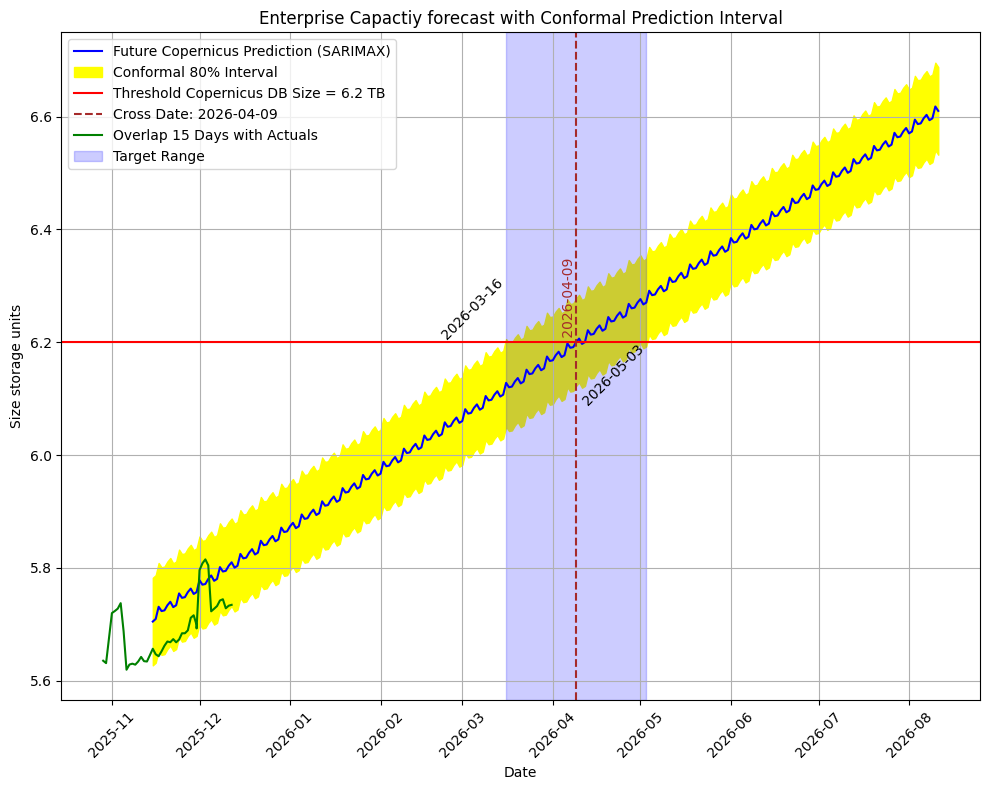

In [ ]:
# ==== Apply to existing manual_model ====
preds_scaled, lower_scaled, upper_scaled, q = conformal_prediction_intervals(
    model_result=manual_result,
    train_endog=train_target_scaled_df.values.ravel(),
    train_exog=train_scaled_df.values,
    val_endog=validation_target_scaled_df.values.ravel(),
    val_exog=validation_scaled_df.values,
    alpha=0.2  # 80% interval
)

q=q*5
# ==== Apply conformal interval to future forecast ====
future_preds_scaled = manual_future_predictions_scaled_avg  # from SARIMAX

future_lower_scaled = future_preds_scaled - q
future_upper_scaled = future_preds_scaled + q

# ==== Inverse transform to original scale ====
future_preds = target_scaler.inverse_transform(future_preds_scaled.reshape(-1, 1)).flatten()
future_lower = target_scaler.inverse_transform(future_lower_scaled.reshape(-1, 1)).flatten()
future_upper = target_scaler.inverse_transform(future_upper_scaled.reshape(-1, 1)).flatten()

# ==== Convert to MB ====
future_preds_mb = future_preds / (1024 * 1024)
future_lower_mb = future_lower / (1024 * 1024)
future_upper_mb = future_upper / (1024 * 1024)

# ==== Plot with Target Marker ====
# Copernicus is 6 TB
target_y_mb = 6.2

plt.figure(figsize=(10, 8))
plt.plot(future_data.index, future_preds_mb, label='Future Copernicus Prediction (SARIMAX)', color='blue')
plt.fill_between(future_data.index, future_lower_mb, future_upper_mb, color='yellow', alpha=1, label='Conformal 80% Interval')
plt.axhline(y=target_y_mb, color='red', linestyle='-', label=f'Threshold Copernicus DB Size = {target_y_mb} TB')

# Find the date when the blue line crosses the red line
cross_date = None
for i in range(len(future_data.index)):
    if future_preds_mb[i] >= target_y_mb:
        cross_date = future_data.index[i]
        break

if cross_date:
    plt.axvline(x=cross_date, color='brown', linestyle='--', label=f'Cross Date: {cross_date.strftime("%Y-%m-%d")}')
    plt.text(cross_date, target_y_mb, f' {cross_date.strftime("%Y-%m-%d")}',
             rotation=90, verticalalignment='bottom', horizontalalignment='right', color='brown')

# Highlight dates where conformal interval contains the target
highlight_dates = future_data.index[
    (future_lower_mb <= target_y_mb) & (future_upper_mb >= target_y_mb)
]
plt.plot(df_daily.index[-45:], df_daily['Size'].iloc[-45:]/(1024*1024), color='green', label='Overlap 15 Days with Actuals')
if not highlight_dates.empty:
    min_highlight_date = highlight_dates.min()
    max_highlight_date = highlight_dates.max()
    plt.axvspan(min_highlight_date, max_highlight_date, color='blue', alpha=0.2, label='Target Range')

    # Add annotations for clarity
    plt.text(max_highlight_date, target_y_mb , max_highlight_date.strftime('%Y-%m-%d'),
             rotation=45,verticalalignment='top', horizontalalignment='right', fontsize=10)
    plt.text(min_highlight_date, target_y_mb , min_highlight_date.strftime('%Y-%m-%d'),
             rotation=45, verticalalignment='bottom', horizontalalignment='right', fontsize=10)
# ==== Final chart formatting ====
plt.xlabel('Date')
plt.ylabel('Size storage units')
plt.title('Enterprise Capactiy forecast with Conformal Prediction Interval')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
#plt.xlim([min(future_data.index),'2027-10-31'])
plt.show()